In [24]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("Retail_Data.csv")

In [35]:
fig = plt.figure(figsize=(18,12))

ax1 = plt.subplot(3,2,1)
ax2 = plt.subplot(3,2,2)
ax3 = plt.subplot(3,2,3)
ax4 = plt.subplot(3,2,4)
ax5 = plt.subplot(3,2,5)
ax6 = plt.subplot(3,2,6)

fig.text(
    0.5, 0.98,
    "Retail Performance Dashboard",
    ha="center",
    va="top",
    fontsize=28,
    fontweight="bold",
    color="navy",
    bbox=dict(
        facecolor="#E3F2FD",
        edgecolor="navy",
        linewidth=2,
        boxstyle="round,pad=0.5"
    )
)

plt.subplots_adjust(top=0.88, hspace=0.6, wspace=0.4)
plt.close(fig)



In [36]:
ax1.axis("off")
ax2.axis("off")
#KPI 1
df["sentiment_level"]=pd.cut(df["customer_sentiment"],bins=[-1,0.5,0.8,1.0,2],labels=["Poor","Fair","Good","Excellent"])
positive_sentiment=(df["sentiment_level"].isin(["Good","Excellent"]).mean()*100)
ax1.set_facecolor("#E8F5E9")

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color("green")
    spine.set_linewidth(3)

ax1.set_xticks([])
ax1.set_yticks([])

ax1.text(
    0.5, 0.70,
    "Positive Customer\nSentiment",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

ax1.text(
    0.5, 0.28,
    f"{positive_sentiment:.1f}%",
    ha="center",
    va="center",
    fontsize=30,
    color="green",
    fontweight="bold"
)

Text(0.5, 0.28, '91.9%')

In [37]:
#KPI -2 Average Return Rate
avg_return_rate=df["return_rate"].mean()*100
ax2.set_facecolor("#FDEDEC")

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color("red")
    spine.set_linewidth(3)

ax2.set_xticks([])
ax2.set_yticks([])

ax2.text(
    0.5, 0.70,
    "Average\nReturn Rate",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

ax2.text(
    0.5, 0.28,
    f"{avg_return_rate:.2f}%",
    ha="center",
    va="center",
    fontsize=30,
    color="red",
    fontweight="bold"
)

Text(0.5, 0.28, '6.34%')

In [38]:
#Visual 1 Promotion intensity by average footfall
df["promotion_group"]=pd.qcut(df["promotion_intensity"],q=4,labels=["Low","Medium","High","Very High"])
promo_footfall=(df.groupby("promotion_group")["footfall"].mean())
promo_footfall.plot(kind="bar",ax=ax3, color="steelblue")


ax3.set_title("Promotion Intesity vs Footfall",fontsize=12,fontweight="bold")
ax3.set_xlabel("Promotion Level")
ax3.set_ylabel("Average Footfall")

ax3.tick_params(axis="x", rotation=0)
ax3.grid(axis="y", linestyle="--", alpha=0.5)


In [39]:
#visual 2 - Ad_spend
df["ad_spend_group"]=pd.qcut(df["ad_spend"],q=4,labels=["Low","Medium","High","Very High"])
promo_ad_spend=(df.groupby("ad_spend_group")["footfall"].mean())
promo_ad_spend.plot(kind="line",ax=ax4,marker="o",linewidth=2,color="orange")

ax4.set_title("Ad_spend vs footfall",fontsize=12,fontweight="bold")
ax4.set_xlabel("Ad Spend Level")
ax4.set_ylabel("Promotion Level")
ax4.grid(axis="y", linestyle="--", alpha=0.5)

ax4.tick_params(axis="x", rotation=0)


In [40]:
# Visual 3 - Customer Sentiment Distribution

sentiment_counts = df["sentiment_level"].value_counts()

sentiment_counts.plot(
    kind="barh",
    ax=ax5,
    color=["#4CAF50", "#2196F3", "#FFC107", "#F44336"]
)

ax5.set_title(
    "Customer Sentiment Distribution",
    fontsize=12,
    fontweight="bold"
)

ax5.set_xlabel("Number of Customers")
ax5.set_ylabel("Sentiment")

ax5.grid(axis="x", linestyle="--", alpha=0.5)
ax5.set_xlim(0, sentiment_counts.max() * 1.20)

# Add values at the end of each bar
for i, value in enumerate(sentiment_counts.values):
    ax5.text(
        value + 50,
        i,
        str(value),
        va="center",
        fontsize=9,
        fontweight="bold"
    )

In [41]:
#visual 4

df["price_difference"]=df["price"]-df["competitor_price"]
df["price_category"]=pd.cut(df["price_difference"],bins=[-100,-2,2,100],labels=['Much Higher','Similar Price','Much Lower'])

price_cat=df["price_category"].value_counts()
price_cat.plot(kind="bar",ax=ax6,color=["green","orange","red"])
ax6.set_title(
    "Pricing Position Relative to Competitors",
    fontsize=12,
    fontweight="bold"
)

ax6.set_xlabel("Pricing Category")
ax6.set_ylabel("Number of Products")

ax6.tick_params(axis="x", rotation=15)

ax6.grid(axis="y", linestyle="--", alpha=0.5)

In [42]:
dashboard=fig
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


<Figure size 640x480 with 0 Axes>

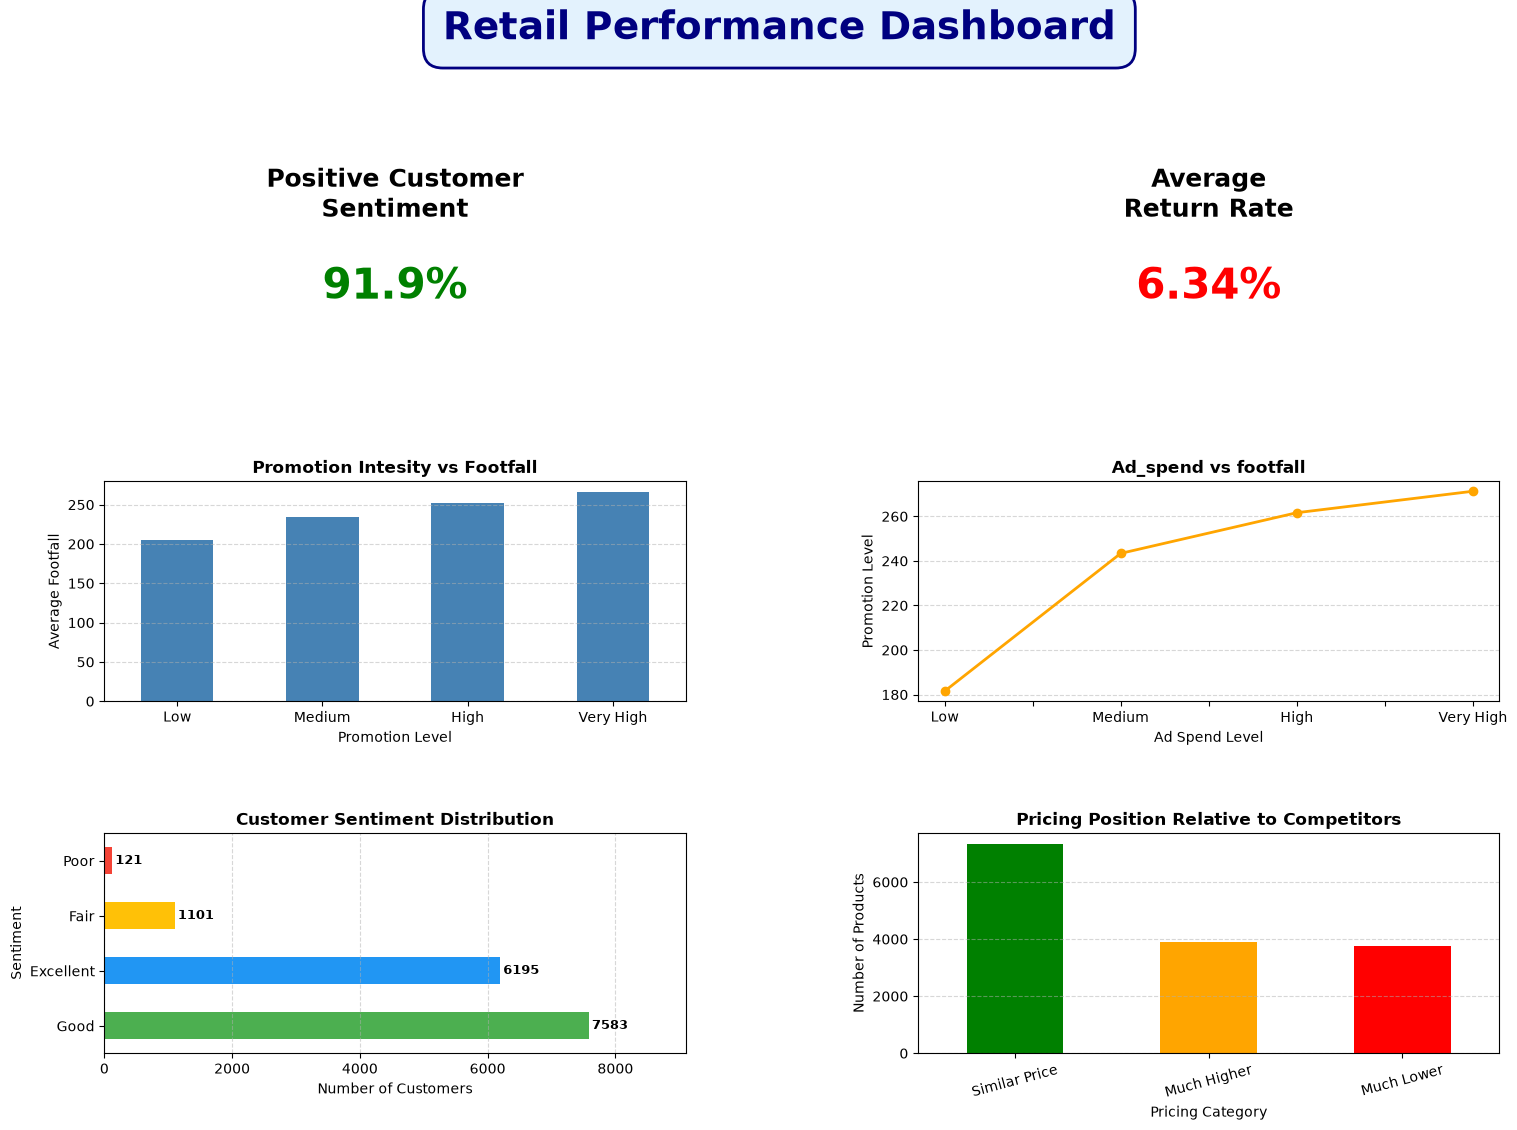

In [43]:
dashboard

In [44]:
plt.tight_layout()

fig.savefig(
    "Retail_Performance_Dashboard.png",
    dpi=300,
    bbox_inches="tight"
)


<Figure size 640x480 with 0 Axes>